# Test Run!
A simple version of the model to test impacts of simplifying the diapause kernel.

In [1]:
%load_ext autoreload
%autoreload 2

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import SpongyMothIPM.meteorology as met
from SpongyMothIPM.config import Config
import SpongyMothIPM.util as util
import SpongyMothIPM.kernels as kernels
import SpongyMothIPM.visualization as viz

## Load Weather Data

In [2]:
df = met.load_daymet_data('../data/mont_st_hilaire/mont_st_hilaire_1980_1991.csv')
df = df[df['year'].isin([1980, 1981, 1982])]
low_time = 1
high_time = 13
sample_period = 4
sample_start_time = 1
temps = met.daymet_to_diurnal(df, 
                            low_time, 
                            high_time, 
                            sample_period, 
                            sample_start_time)


config = Config(dtype=torch.float,
                delta_t=sample_period/24)

days = len(temps)//(24//sample_period)

## Model Setup

In [9]:
class SimpleModel():
    def __init__(self):
        # Build life stages
        self.prediapause = kernels.Prediapause(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/prediapause.csv')
        self.diapause = kernels.Diapause(
            config, n_bins_I=50, n_bins_D=50, save=True, save_rate=1, mortality=0, sigma_I=0.1, sigma_D=0.1,
            file_path='memory')#../outputs/test_run/diapause.csv')
        self.postdiapause = kernels.Postdiapause(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/postdiapause.csv')
        self.first_instar = kernels.FirstInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1, 
            file_path='../outputs/test_run/first_instar.csv')
        self.second_instar = kernels.SecondInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/second_instar.csv')
        self.third_instar = kernels.ThirdInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/third_instar.csv')
        self.fourth_instar = kernels.FourthInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/fourth_instar.csv')
        self.male_late_instar = kernels.MaleFifthInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/male_late_instar.csv')
        self.female_late_instar = kernels.FemaleFifthSixthInstar(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/female_late_instar.csv')
        self.male_pupae = kernels.MalePupae(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/male_pupae.csv')
        self.female_pupae = kernels.FemalePupae(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/female_pupae.csv')
        self.adults = kernels.Adult(
            config, save=True, save_rate=1, mortality=0, sigma=0.1,
            file_path='../outputs/test_run/adult.csv')
        
        # Gather parameters together for optimization.
        self.parameters = [self.prediapause.sigma,
                           self.diapause.sigma_D,
                           self.diapause.sigma_I,
                           self.postdiapause.sigma,
                           self.first_instar.sigma,
                           self.second_instar.sigma,
                           self.third_instar.sigma,
                           self.fourth_instar.sigma,
                           self.male_late_instar.sigma,
                           self.female_late_instar.sigma,
                           self.male_pupae.sigma,
                           self.female_pupae.sigma,
                           self.adults.sigma]
        
    def init_pop(self):
        # Initiate populations
        mu = 0.2
        sigma = 1.1
        total = 1
        empty = 0
        self.prediapause.init_pop(empty, mu, sigma)
        # Individuals all begin in the prediapause stage at the same time.
        self.prediapause.add_transfers(total) 
        self.diapause.init_pop(empty, mu, sigma)
        self.postdiapause.init_pop(empty, mu, sigma)
        self.first_instar.init_pop(empty, mu, sigma)
        self.second_instar.init_pop(empty, mu, sigma)
        self.third_instar.init_pop(empty, mu, sigma)
        self.fourth_instar.init_pop(empty, mu, sigma)
        self.male_late_instar.init_pop(empty, mu, sigma)
        self.female_late_instar.init_pop(empty, mu, sigma)
        self.male_pupae.init_pop(empty, mu, sigma)
        self.female_pupae.init_pop(empty, mu, sigma)
        self.adults.init_pop(empty, mu, sigma)
    
    def run_one_time_step(self, 
                          year, 
                          doy, 
                          doy_temps,
                          record_start_year, 
                          record_start_doy,
                          record_end_year,
                          record_end_doy,
                          save):
        transfers = self.prediapause.run_one_step(doy_temps)
        print(self.diapause._pop.shape)
        transfers = self.diapause.run_one_step(doy_temps, transfers)
        print(self.diapause._pop.shape)
        transfers = self.postdiapause.run_one_step(doy_temps, transfers)

        # Record transfers to first instars
        # if record_start_year <= year <= record_end_year: 
        #     if record_start_doy <= doy <= record_end_doy:
        #         if save and not self.first_instar.save:
        #             self.first_instar.save = True
        #         self.hatched[year].append(transfers)
        #     else:
        #         self.first_instar.save = False

        transfers = self.first_instar.run_one_step(doy_temps, transfers)
        transfers = self.second_instar.run_one_step(doy_temps, transfers)
        transfers = self.third_instar.run_one_step(doy_temps, transfers)
        transfers_dif = self.fourth_instar.run_one_step(doy_temps, transfers)
        transfers = self.male_late_instar.run_one_step(doy_temps, transfers_dif/2)
        to_adult = self.male_pupae.run_one_step(doy_temps, transfers)
        transfers = self.female_late_instar.run_one_step(doy_temps, transfers_dif/2)
        to_adult += self.female_pupae.run_one_step(doy_temps, transfers)
        transfers = self.adults.run_one_step(doy_temps, to_adult)
        self.prediapause.add_transfers(transfers/2)

    def forward(self, 
                start_doy,
                record_start_year, 
                record_start_doy,
                record_end_year,
                record_end_doy,
                save):
        # Run Model
        start_year = temps['year'].min()
        end_year = temps['year'].max()
        start = (24//sample_period)*(start_doy-1)
        # For tracking emerging eggs
        self.hatched = {year:[] 
                        for year in range(record_start_year, 
                                          record_end_year+1)}
        for year in range(start_year, end_year+1):
            #print(f"Starting year {year}")
            days = temps.loc[temps['year'] == year, 'yday'].max()
            if year > start_year:
                start_doy = 1
            for doy in range(start_doy, days+1):
                end = start + (24//sample_period)
                doy_temps = temps.iloc[start:end]
                if not (record_start_year <= year <= record_end_year):
                    # While we are not in the year of interest, we will not bother
                    # tracking gradients as it is very memory intensive.
                    with torch.no_grad():
                        self.run_one_time_step(year, 
                                              doy, 
                                              doy_temps,
                                              record_start_year, 
                                              record_start_doy,
                                              record_end_year,
                                              record_end_doy,
                                              save)
                else:
                    self.run_one_time_step(year, 
                                          doy, 
                                          doy_temps,
                                          record_start_year, 
                                          record_start_doy,
                                          record_end_year,
                                          record_end_doy,
                                          save)
                start = end
                break
            break

In [10]:
with torch.no_grad():
    model = SimpleModel()
    model.init_pop()
    model.forward(250, 1980, 0, 1983, 365, True)

torch.Size([2500])
torch.Size([2500, 2500])


In [6]:
model.diapause._pop.shape

torch.Size([2500, 2500])

In [5]:
df_prediapause = pd.read_csv('../outputs/test_run/prediapause.csv', header=0, index_col=[0,1])
df_diapause = pd.read_csv('../outputs/test_run/diapause.csv', header=0, index_col=[0,1])
df_postdiapause = pd.read_csv('../outputs/test_run/postdiapause.csv', header=0, index_col=[0,1])
df_first_instar = pd.read_csv('../outputs/test_run/first_instar.csv', header=0, index_col=[0,1])
df_second_instar = pd.read_csv('../outputs/test_run/second_instar.csv', header=0, index_col=[0,1])
df_third_instar = pd.read_csv('../outputs/test_run/third_instar.csv', header=0, index_col=[0,1])
df_fourth_instar = pd.read_csv('../outputs/test_run/fourth_instar.csv', header=0, index_col=[0,1])
df_male_late_instar = pd.read_csv('../outputs/test_run/male_late_instar.csv', header=0, index_col=[0,1])
df_female_late_instar = pd.read_csv('../outputs/test_run/female_late_instar.csv', header=0, index_col=[0,1])
df_male_pupae = pd.read_csv('../outputs/test_run/male_pupae.csv', header=0, index_col=[0,1])
df_female_pupae = pd.read_csv('../outputs/test_run/female_pupae.csv', header=0, index_col=[0,1])
df_adult = pd.read_csv('../outputs/test_run/adult.csv', header=0, index_col=[0,1])

KeyboardInterrupt: 

In [ ]:
dfs = [df_prediapause,
       df_diapause,
       df_postdiapause,
       df_first_instar,
       df_second_instar,
       df_third_instar,
       df_fourth_instar,
       df_male_late_instar,
       df_female_late_instar,
       df_male_pupae,
       df_female_pupae,
       df_adult]
names = ['Prediapause',
         'Diapause',
         'Postdiapause',
         'First Instar',
         'Second Instar',
         'Third Instar',
         'Fourth Instar',
         'Male Fifth Instar',
         'Female Fifth/Sixth Instar',
         'Male Pupae',
         'Female Pupae',
         'Adult']
styles = [{'color':'blue', 'linestyle':'dotted', 'linewidth':5}, # Prediapause
          {'color':'blue', 'linestyle':'solid', 'linewidth':5}, # Diapause
          {'color':'blue', 'linestyle':'dashed', 'linewidth':5}, # Postdiapause
          {'color':'purple', 'linestyle':'dotted', 'linewidth':5}, # First Instar
          {'color':'purple', 'linestyle':'dashed', 'dashes':(3, 2, 1, 2), 'linewidth':5}, # Second Instar
          {'color':'purple', 'linestyle':'dashed', 'linewidth':5}, # Third Instar
          {'color':'purple', 'linestyle':'solid', 'linewidth':5}, # Fourth Instar
          {'color':'darkgreen', 'linestyle':'dashed', 'linewidth':5}, # Male Fifth Instar
          {'color':'darkgreen', 'linestyle':'solid', 'linewidth':5}, # Female Fifth/Sixth Instar
          {'color':'brown', 'linestyle':'dashed', 'linewidth':5}, # Male Pupae
          {'color':'brown', 'linestyle':'solid', 'linewidth':5}, # Female Pupae
          {'color':'black', 'linestyle':'solid', 'linewidth':5}, # Adult
          ]

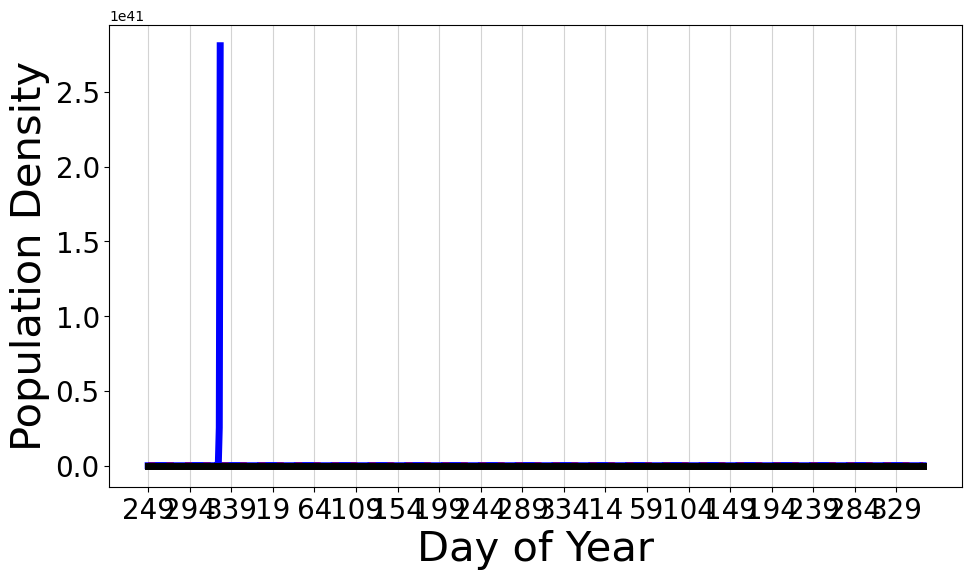

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

viz.plot_abundances(ax, dfs, names, styles, tick_freq=45, label_fontsize=30)

In [110]:
idx = pd.IndexSlice
t = df_prediapause.loc[idx[1980]].sum(axis=1)

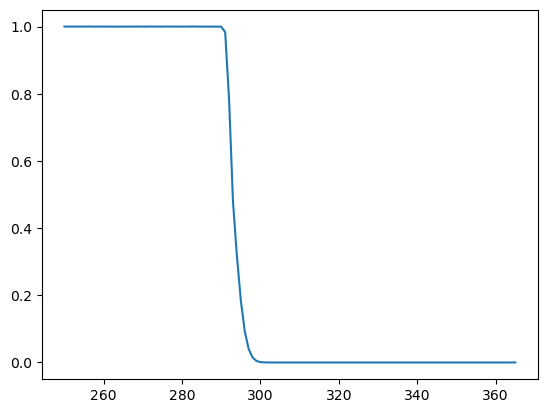

In [111]:
fig, ax = plt.subplots()
ax.plot(t)

In [82]:
t

yday
250    0.0
251    0.0
252    0.0
253    0.0
254    0.0
      ... 
361    0.0
362    0.0
363    0.0
364    0.0
365    0.0
Length: 116, dtype: float64

In [84]:
df_prediapause.loc[idx[1981]]

,0.0000,0.0101,0.0202,0.0303,0.0404,0.0505,0.0606,0.0707,0.0808,0.0909,...,0.9091,0.9192,0.9293,0.9394,0.9495,0.9596,0.9697,0.9798,0.9899,1.0000
yday,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
